In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

In [2]:
df = pd.read_csv('/content/Advertising (2).csv')
df

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9
...,...,...,...,...,...
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5


In [3]:
df.shape

(200, 5)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   radio       200 non-null    float64
 3   newspaper   200 non-null    float64
 4   sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [5]:
df.describe()

,Unnamed: 0,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [6]:
df.describe()

,Unnamed: 0,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [7]:
df.isnull().sum()

,0
Unnamed: 0,0
TV,0
radio,0
newspaper,0
sales,0


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df = df.drop(columns=['Unnamed: 0'])

In [10]:
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [11]:
df.median()

,0
TV,149.75
radio,22.90
newspaper,25.75
sales,12.90


In [12]:
df.corr()

,TV,radio,newspaper,sales
TV,1.000000,0.054809,0.056648,0.782224
radio,0.054809,1.000000,0.354104,0.576223
newspaper,0.056648,0.354104,1.000000,0.228299
sales,0.782224,0.576223,0.228299,1.000000


<Figure size 1000x600 with 0 Axes>

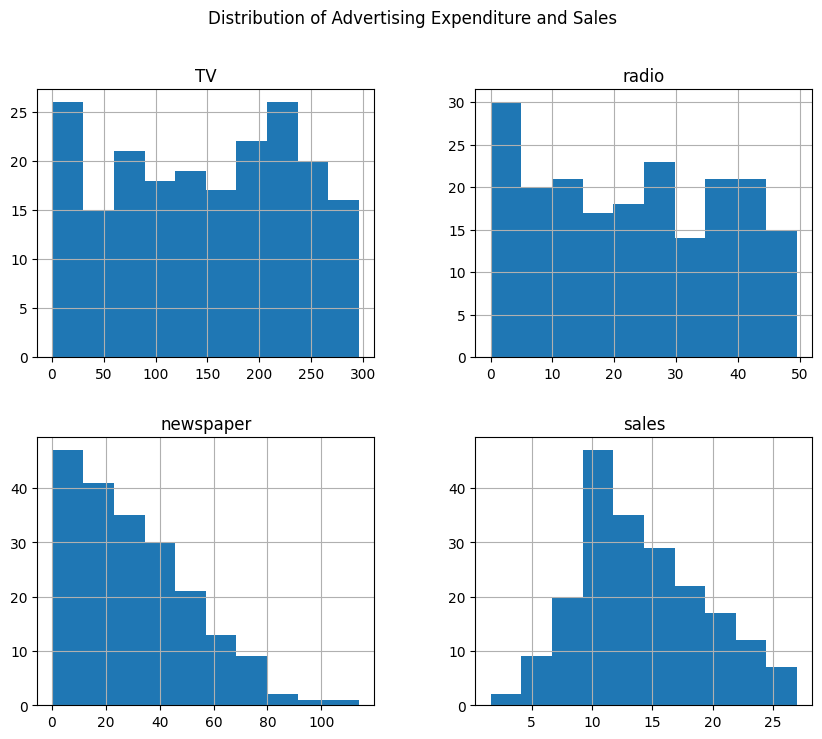

In [13]:
plt.figure(figsize=(10, 6))
df.hist(figsize=(10, 8))
plt.suptitle("Distribution of Advertising Expenditure and Sales")
plt.savefig("histograms.png", dpi=300, bbox_inches="tight")
plt.show()

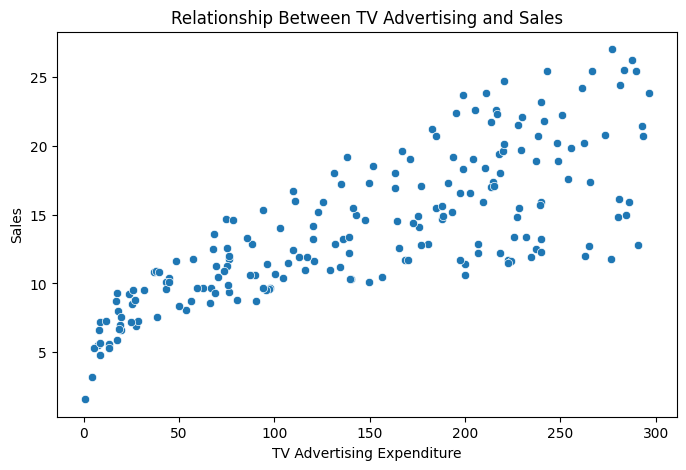

In [14]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x='TV', y='sales')

plt.title("Relationship Between TV Advertising and Sales")
plt.xlabel("TV Advertising Expenditure")
plt.ylabel("Sales")
plt.savefig("tv_sales_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

In [18]:
correlation, p_value = stats.pearsonr(df['TV'], df['sales'])

print("Pearson Correlation:", correlation)
print("P-value:", p_value)

Pearson Correlation: 0.7822244248616067
P-value: 1.467389700194602e-42


In [19]:
X = df[['TV']]
y = df['sales']

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.612
Model:                            OLS   Adj. R-squared:                  0.610
Method:                 Least Squares   F-statistic:                     312.1
Date:                Mon, 24 Aug 2026   Prob (F-statistic):           1.47e-42
Time:                        18:00:34   Log-Likelihood:                -519.05
No. Observations:                 200   AIC:                             1042.
Df Residuals:                     198   BIC:                             1049.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.0326      0.458     15.360      0.0

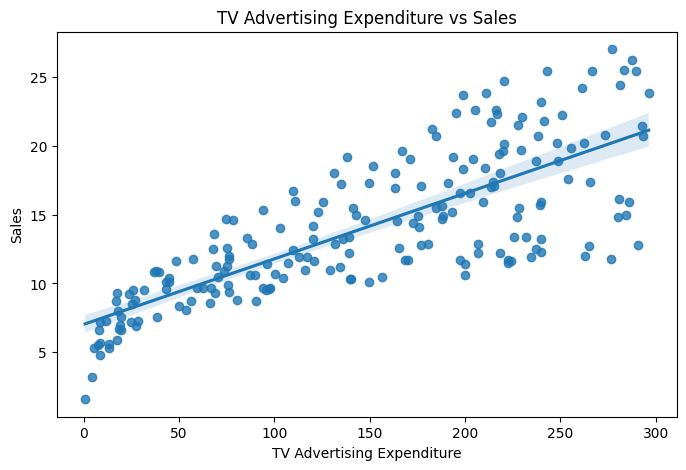

In [20]:
plt.figure(figsize=(8, 5))

sns.regplot(data=df, x='TV', y='sales')

plt.title("TV Advertising Expenditure vs Sales")
plt.xlabel("TV Advertising Expenditure")
plt.ylabel("Sales")
plt.savefig("regression_plot.png", dpi=300, bbox_inches="tight")
plt.show()

In [21]:
residuals = model.resid
print(residuals.head())

0    4.129225
1    1.252026
2    1.449776
3    4.265605
4   -2.727218
dtype: float64


In [22]:
print("Mean of residuals:", residuals.mean())

Mean of residuals: -6.892264536872972e-15


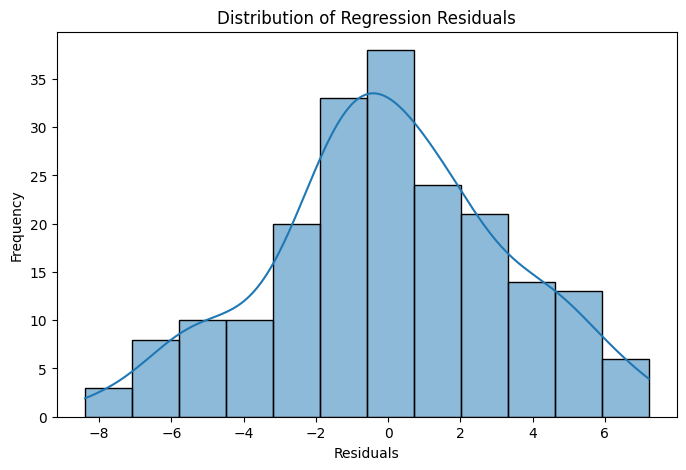

In [23]:
plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True)
plt.title("Distribution of Regression Residuals")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.savefig("residual_histogram.png", dpi=300, bbox_inches="tight")
plt.show()

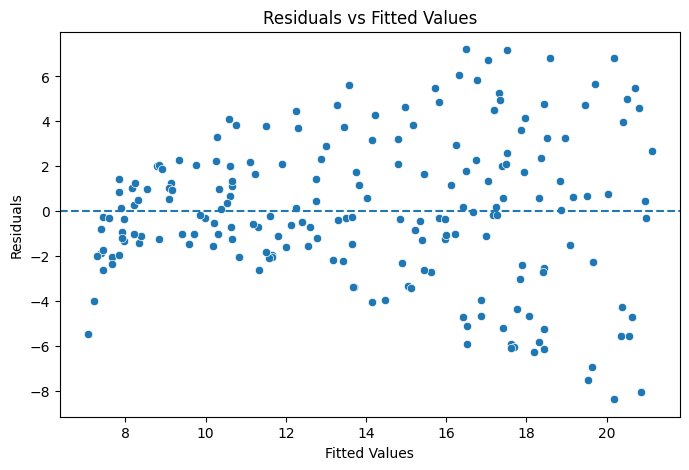

In [24]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=model.fittedvalues, y=residuals)
plt.axhline(y=0, linestyle='--')
plt.title("Residuals vs Fitted Values")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.savefig("residual_plot.png", dpi=300, bbox_inches="tight")
plt.show()

In [25]:
shapiro_stat, shapiro_p = stats.shapiro(residuals)
print("Shapiro-Wilk Statistic:", shapiro_stat)
print("Shapiro-Wilk P-value:", shapiro_p)

Shapiro-Wilk Statistic: 0.9905306561484956
Shapiro-Wilk P-value: 0.2133255143672237


In [26]:
confidence_interval = model.conf_int()
print("95% Confidence Intervals:")
print(confidence_interval)

95% Confidence Intervals:
              0         1
const  6.129719  7.935468
TV     0.042231  0.052843


In [27]:
print("TV coefficient:", model.params['TV'])
print("TV p-value:", model.pvalues['TV'])
print("R-squared:", model.rsquared)

TV coefficient: 0.047536640433019764
TV p-value: 1.467389700194655e-42
R-squared: 0.611875050850071


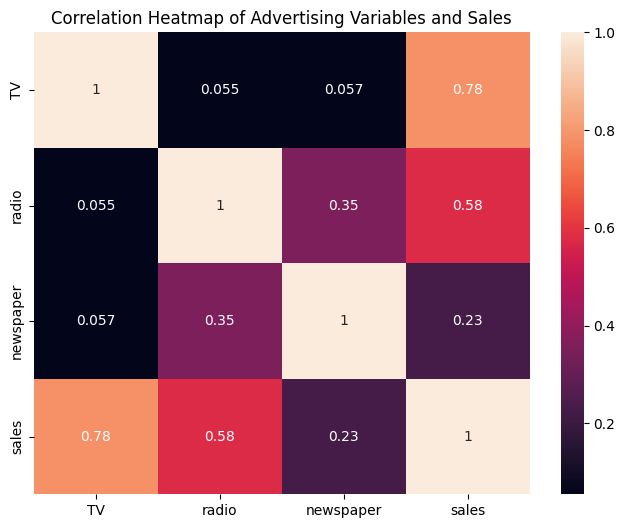

In [28]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Heatmap of Advertising Variables and Sales")
plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()